<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Loss Function, Gradient Descent e a Origem do MSE

Notebook complementar do artigo publicado no [blog Sigmoidal](https://sigmoidal.ai).

Segundo da série **Matemática para Machine Learning**. Aqui definimos a função de custo
(MSE), implementamos o gradient descent do zero para treinar uma regressão linear e
visualizamos a superfície de custo. A notação é a do curso de Andrew Ng.

## Importações e configurações

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

np.random.seed(42)

## 1. Dados e modelo

Geramos dados sintéticos de uma única feature em torno de $y = 2x + 1$ com ruído. O modelo
de regressão linear, na notação do curso, é $f_{w,b}(x) = w x + b$.

In [2]:
# Dados sinteticos: y ~ 2x + 1 + ruido gaussiano
m = 50
x = np.linspace(0, 10, m)
y = 2 * x + 1 + np.random.randn(m) * 1.5


def modelo(x, w, b):
    """Predicao da regressao linear para uma feature."""
    return w * x + b

## 2. A função de custo (MSE)

A **loss** mede o erro em um único exemplo; a **cost** é a média sobre os $m$ exemplos. Para
a regressão linear usamos o erro quadrático médio (MSE), com um fator $\tfrac{1}{2}$ que
simplifica a derivada:

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2.$$

In [3]:
def custo(x, y, w, b):
    """Cost function (MSE com fator 1/2) da regressao linear."""
    erro = modelo(x, w, b) - y
    return np.mean(erro ** 2) / 2


# Custo de um conjunto de parametros chutados
print("J(w=0, b=0)   =", round(custo(x, y, 0.0, 0.0), 3))
print("J(w=2, b=1)   =", round(custo(x, y, 2.0, 1.0), 3))

J(w=0, b=0)   = 73.636
J(w=2, b=1)   = 1.018


## 3. A superfície de custo: a tigela

Com os dados fixos, $J(w, b)$ é uma função apenas dos parâmetros. Como o custo é uma soma
de quadrados de funções lineares em $w$ e $b$, a superfície é convexa, com um único mínimo:
uma tigela. Vista de cima, as curvas de nível são elipses concêntricas em torno do ponto
ótimo.

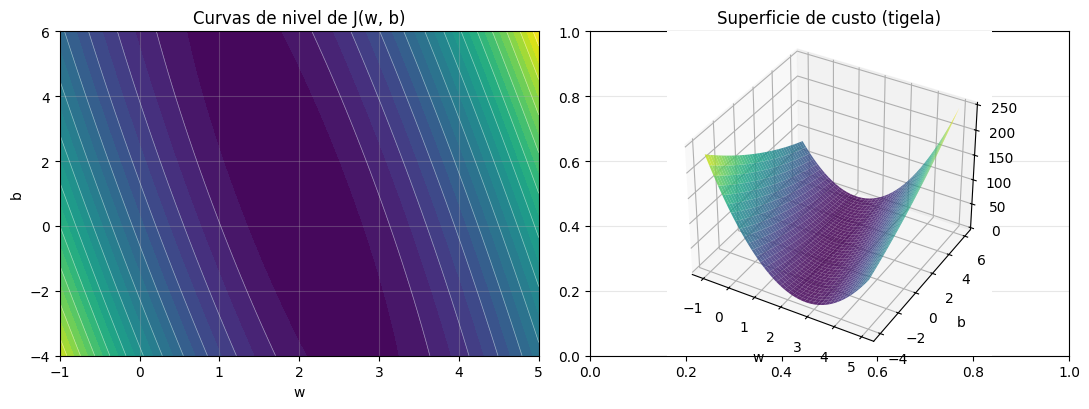

In [4]:
# Grade de parametros em torno do otimo
w_grade = np.linspace(-1, 5, 120)
b_grade = np.linspace(-4, 6, 120)
WW, BB = np.meshgrid(w_grade, b_grade)
JJ = np.array([[custo(x, y, w, b) for w in w_grade] for b in b_grade])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.contourf(WW, BB, JJ, levels=25, cmap="viridis")
ax1.contour(WW, BB, JJ, levels=12, colors="white", linewidths=0.5, alpha=0.5)
ax1.set_xlabel("w")
ax1.set_ylabel("b")
ax1.set_title("Curvas de nivel de J(w, b)")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(WW, BB, JJ, cmap="viridis", alpha=0.85, linewidth=0)
ax2.set_xlabel("w")
ax2.set_ylabel("b")
ax2.set_title("Superficie de custo (tigela)")
ax2.view_init(elev=35, azim=-60)

plt.tight_layout()
plt.show()

## 4. Gradient descent

O gradiente do custo em relação aos parâmetros, depois que o fator $\tfrac{1}{2}$ cancela
o $2$ da derivada do quadrado, é

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) x^{(i)},
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right).$$

A regra de atualização desce a tigela com passos proporcionais ao learning rate $\alpha$,
sempre com **atualização simultânea** de $w$ e $b$.

In [5]:
def gradiente(x, y, w, b):
    """Derivadas parciais do custo em relacao a w e b."""
    erro = modelo(x, w, b) - y
    dw = np.mean(erro * x)
    db = np.mean(erro)
    return dw, db


def gradient_descent(x, y, w, b, alpha, n_iter):
    """Treina a regressao linear; retorna parametros, historico do custo e caminho (w, b)."""
    historico = []
    caminho = [(w, b)]
    for _ in range(n_iter):
        dw, db = gradiente(x, y, w, b)
        w = w - alpha * dw      # atualizacao simultanea: usa os mesmos w, b
        b = b - alpha * db
        historico.append(custo(x, y, w, b))
        caminho.append((w, b))
    return w, b, historico, np.array(caminho)

In [6]:
w, b, historico, caminho = gradient_descent(x, y, w=0.0, b=0.0, alpha=0.02, n_iter=2000)

print(f"w treinado = {w:.3f}  (gerador usou 2.0)")
print(f"b treinado = {b:.3f}  (gerador usou 1.0)")
print(f"custo final = {historico[-1]:.4f}")

w treinado = 1.913  (gerador usou 2.0)
b treinado = 1.097  (gerador usou 1.0)
custo final = 0.9283


## 5. A descida sobre a tigela

À esquerda, o caminho percorrido por $(w, b)$ a cada iteração, sobreposto às curvas de nível
do custo: partindo da origem, o gradient descent desce até o mínimo. À direita, o mesmo
processo visto como a queda do custo ao longo das iterações.

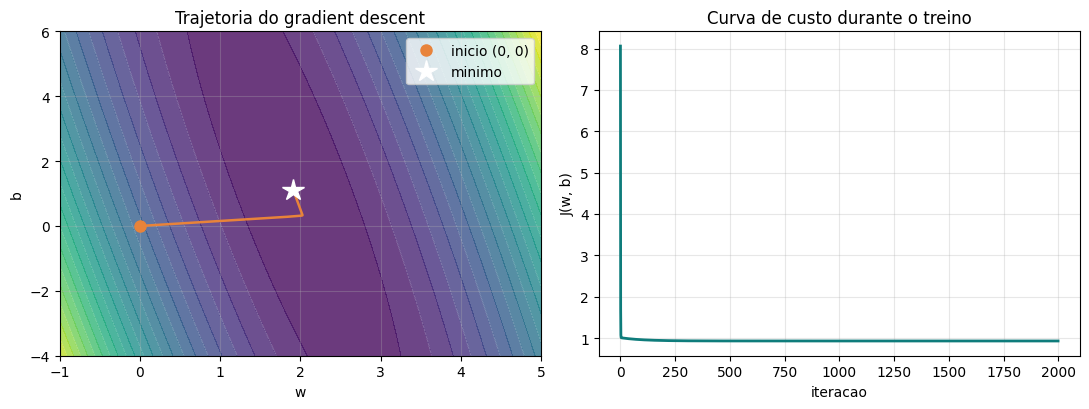

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.contourf(WW, BB, JJ, levels=25, cmap="viridis", alpha=0.8)
ax1.contour(WW, BB, JJ, levels=12, colors="white", linewidths=0.5, alpha=0.4)
ax1.plot(caminho[:, 0], caminho[:, 1], color="#E8833A", lw=1.8)
ax1.plot(*caminho[0], "o", color="#E8833A", ms=8, label="inicio (0, 0)")
ax1.plot(*caminho[-1], "*", color="white", ms=16, label="minimo")
ax1.set_xlabel("w")
ax1.set_ylabel("b")
ax1.set_title("Trajetoria do gradient descent")
ax1.legend(loc="upper right")

ax2.plot(historico, color="#0E7C7B", lw=2)
ax2.set_xlabel("iteracao")
ax2.set_ylabel("J(w, b)")
ax2.set_title("Curva de custo durante o treino")

plt.tight_layout()
plt.show()

## 6. A reta ajustada

A reta encontrada pelo gradient descent sobre os dados, com os parametros recuperados.

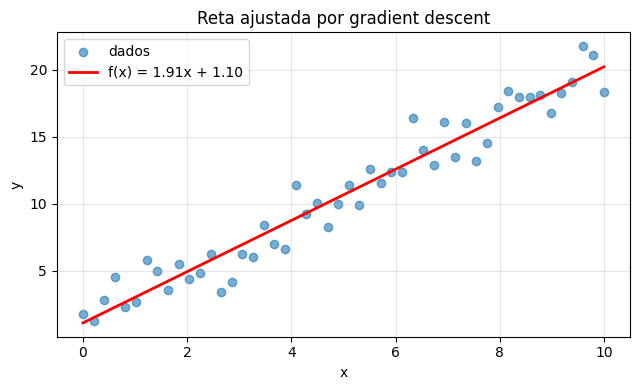

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(x, y, alpha=0.6, label="dados")
ax.plot(x, modelo(x, w, b), "r-", lw=2, label=f"f(x) = {w:.2f}x + {b:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Reta ajustada por gradient descent")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Por que o MSE? A hipótese de ruído gaussiano

O MSE não é uma escolha arbitrária. Se assumimos que os dados seguem
$y^{(i)} = f_{w,b}(x^{(i)}) + \varepsilon^{(i)}$ com ruído gaussiano
$\varepsilon^{(i)} \sim \mathcal{N}(0, \sigma^2)$, maximizar a verossimilhança dos dados é
matematicamente equivalente a minimizar o MSE. A consequência geométrica é que a reta deixa
de ser a previsão e passa a ser o **centro** de uma distribuição: para cada $x$, existe uma
gaussiana de valores possíveis de $y$ centrada na reta.

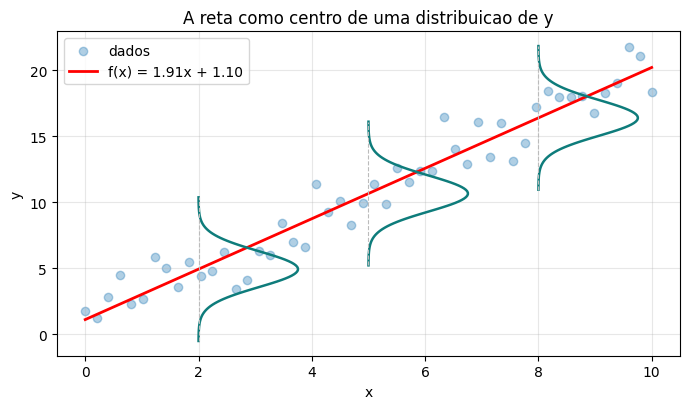

In [9]:
def gaussiana(t, mu, sigma):
    """Densidade da normal N(mu, sigma^2)."""
    return np.exp(-((t - mu) ** 2) / (2 * sigma ** 2)) / (sigma * np.sqrt(2 * np.pi))


sigma = (y - modelo(x, w, b)).std()

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(x, y, alpha=0.35, label="dados")
xx = np.linspace(0, 10, 100)
ax.plot(xx, modelo(xx, w, b), "r-", lw=2, label=f"f(x) = {w:.2f}x + {b:.2f}")

# Sininhos gaussianos em torno da reta, em alguns pontos de x
for x0 in [2, 5, 8]:
    centro = modelo(x0, w, b)
    yy = np.linspace(centro - 4 * sigma, centro + 4 * sigma, 100)
    dens = gaussiana(yy, centro, sigma)
    ax.plot(x0 + dens * 6, yy, color="#0E7C7B", lw=1.8)     # bell deitado ao longo da reta
    ax.vlines(x0, yy.min(), yy.max(), color="#bbb", lw=0.8, linestyles="dashed")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("A reta como centro de uma distribuicao de y")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Os resíduos do modelo treinado devem, então, parecer ruído gaussiano em torno de zero.

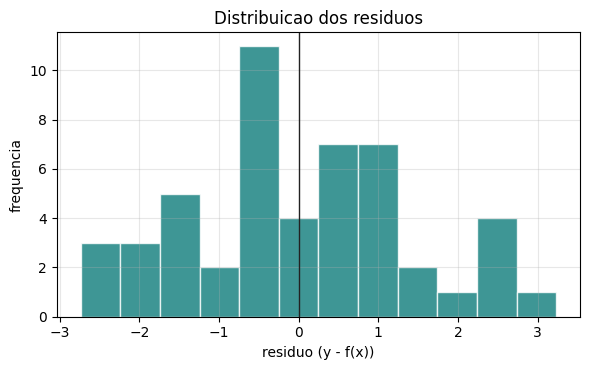

media dos residuos = 0.000  (esperado ~ 0)
desvio padrao      = 1.363


In [10]:
residuos = y - modelo(x, w, b)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.hist(residuos, bins=12, color="#0E7C7B", alpha=0.8, edgecolor="white")
ax.axvline(0, color="#222", lw=1)
ax.set_xlabel("residuo (y - f(x))")
ax.set_ylabel("frequencia")
ax.set_title("Distribuicao dos residuos")
plt.tight_layout()
plt.show()

print(f"media dos residuos = {residuos.mean():.3f}  (esperado ~ 0)")
print(f"desvio padrao      = {residuos.std():.3f}")

## Recapitulando

- A **cost function** resume o erro do modelo em um único número; o MSE é a média dos erros
  ao quadrado.
- A superfície $J(w, b)$ é uma **tigela convexa** com um único mínimo.
- O **gradient descent** desce essa tigela usando apenas as derivadas, recuperando os
  parâmetros que geraram os dados.
- O MSE é uma **consequência** de assumir ruído gaussiano, via Maximum Likelihood Estimation.

No próximo notebook trocamos a distribuição do ruído pela de Bernoulli e obtemos, com a mesma
receita, a binary cross-entropy da classificação.